# Qiskit Example: Modeling $\textrm{H}_2$ using SQD

`H2_VQE_example.ipynb` ended on an uncomfortable note: run UCCSD
through a real device's calibrated noise and the energy comes out roughly
$0.11$ Hartree **above** FCI -- worse than Hartree-Fock, recovering a
negative fraction of the correlation energy. That error is a *bias*, not
scatter: more shots shrink the spread around it but leave the offset
untouched.

This notebook attacks the same problem a different way. **Sample-based
Quantum Diagonalization** asks the quantum device for much less: not an
expectation value, just a list of *which electronic configurations
matter*. It measures the ansatz in the computational basis, collects the
determinants that appear, projects the Hamiltonian onto their span, and
diagonalizes that small matrix classically and exactly.

The consequence is the whole point:

> Noise corrupts **which bitstrings** you see. It cannot corrupt the
> eigenvalue, because the eigenvalue never came from the device.

The result is variational -- an upper bound on the true ground-state
energy, approached from above as the subspace improves, and one that can
never fall below FCI.

Sections 0-2 build the same integrals -> Jordan-Wigner Hamiltonian ->
UCCSD circuit pipeline as `H2_VQE_example.ipynb`, but this time via
`qiskit-nature` rather than by hand -- that notebook already showed what
those objects are made of, so there is no need to rebuild them from
scratch again here. Everything from Section 3 on is new.

## 0. Setup

In [1]:
import numpy as np
from itertools import combinations
%matplotlib inline
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

print("NumPy version:", np.__version__)
import pyscf
print("PySCF version:", pyscf.__version__)
import qiskit
print("Qiskit version:", qiskit.__version__)
import qiskit_aer
print("Qiskit Aer version:", qiskit_aer.__version__)
import qiskit_ibm_runtime
print("Qiskit IBM Runtime version:", qiskit_ibm_runtime.__version__)
import qiskit_nature
print("Qiskit Nature version:", qiskit_nature.__version__)

NumPy version: 2.5.3
PySCF version: 2.14.0
Qiskit version: 2.5.2
Qiskit Aer version: 0.17.2
Qiskit IBM Runtime version: 0.49.0
Qiskit Nature version: 0.8.0



## 1. Build the $\textrm{H}_2$ molecule and run Hartree-Fock

STO-3G (2 spatial orbitals, 4 spin-orbitals = 4 qubits) at the experimental
equilibrium bond length 0.7414 Å.


In [2]:

from pyscf import gto, scf

mol = gto.M(atom='H 0 0 0; H 0 0 0.7414', basis='sto-3g', unit='Angstrom', verbose=0)
mf = scf.RHF(mol).run()

print(f"Molecule: H2, bond length 0.7414 Angstrom, basis STO-3G")
print(f"Number of electrons: {mol.nelectron}")
print(f"Number of spatial molecular orbitals: {mf.mo_coeff.shape[1]}")
print(f"Number of spin-orbitals (qubits needed): {2 * mf.mo_coeff.shape[1]}")
print(f"RHF total energy = {mf.e_tot:.8f} Hartree")


Molecule: H2, bond length 0.7414 Angstrom, basis STO-3G
Number of electrons: 2
Number of spatial molecular orbitals: 2
Number of spin-orbitals (qubits needed): 4
RHF total energy = -1.11668439 Hartree


## 2. Map to qubits and build the UCCSD ansatz with Qiskit Nature

`H2_VQE_example.ipynb` built this pipeline entirely by hand -- spin-orbital
integrals in block-spin ordering, symbolic Pauli algebra, Jordan-Wigner
creation/annihilation operators, a generic Pauli-exponential circuit
primitive, and the UCCSD ansatz assembled excitation by excitation -- to
show exactly what a qubit Hamiltonian and a UCCSD circuit are made of.
That was the point of that notebook; it is not the point of this one, so
we do not rebuild it here. **`qiskit-nature`** does the same job in three
calls: a driver that hands PySCF's integrals to a `Hamiltonian` object, a
`JordanWignerMapper` that turns it into a `SparsePauliOp`, and a
`UCCSD`/`HartreeFock` pair that builds the identical ansatz.

Two conventions are worth being explicit about, since Section 3 onward
still works directly with bitstrings and needs to know exactly what they
mean:

- **Qubit ordering matches.** Qiskit Nature lays out spin-orbitals exactly
  the way the VQE notebook did by hand: qubits $0,1$ are the $\alpha$
  copies of spatial orbitals $0,1$; qubits $2,3$ their $\beta$ copies. The
  Hartree-Fock circuit built below occupies qubits $0$ and $2$, confirming
  it -- this was checked directly against the hand-built Hamiltonian
  before relying on it.
- **Label convention does not.** `SparsePauliOp` uses Qiskit's own string
  order (leftmost character = highest-numbered qubit), the opposite of
  this notebook's convention (label[0] = qubit 0, used throughout Section
  3's bit-manipulation code). Every label gets reversed on the way in.
  `qiskit-nature`'s Hamiltonian also reports the *electronic* energy only
  -- nuclear repulsion is added back into the identity coefficient by
  hand, to match what `build_qubit_hamiltonian_pauli` did in the VQE
  notebook.

In [3]:
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper

driver = PySCFDriver(
    atom='H 0 0 0; H 0 0 0.7414', basis='sto3g',
    charge=0, spin=0, unit=DistanceUnit.ANGSTROM,
)
problem = driver.run()
n_mo = problem.num_spatial_orbitals
n_so = 2 * n_mo
n_alpha, n_beta = problem.num_particles

mapper = JordanWignerMapper()
qubit_op = mapper.map(problem.hamiltonian.second_q_op())

# reverse each label to this notebook's convention (label[0] = qubit 0),
# and fold the nuclear repulsion energy into the identity term
H_pauli = {}
for label, coeff in zip(qubit_op.paulis.to_labels(), qubit_op.coeffs):
    rev = label[::-1]
    H_pauli[rev] = H_pauli.get(rev, 0.0) + coeff.real
H_pauli['I' * n_so] = H_pauli.get('I' * n_so, 0.0) + problem.hamiltonian.nuclear_repulsion_energy

print(f"n_mo = {n_mo} spatial orbitals -> n_so = {n_so} spin-orbitals (qubits)")
print(f"n_alpha = {n_alpha}, n_beta = {n_beta}")
print(f"Qubit Hamiltonian: {len(H_pauli)} nonzero Pauli terms\n")
for label, coeff in sorted(H_pauli.items(), key=lambda x: -abs(x[1])):
    print(f"  {label} : {coeff:+.8f}")

from pyscf import fci
e_fci, _ = fci.FCI(mf).kernel()
print(f"\n(for reference: PySCF FCI ground-state energy = {e_fci:.8f} Hartree)")

n_mo = 2 spatial orbitals -> n_so = 4 spin-orbitals (qubits)
n_alpha = 1, n_beta = 1
Qubit Hamiltonian: 15 nonzero Pauli terms

  IZII : -0.22278593
  IIIZ : -0.22278593
  IZIZ : +0.17434844
  ZIII : +0.17119775
  IIZI : +0.17119775
  ZIZI : +0.16862219
  ZIIZ : +0.16586702
  IZZI : +0.16586702
  ZZII : +0.12054482
  IIZZ : +0.12054482
  IIII : -0.09886397
  YYYY : +0.04532220
  YYXX : +0.04532220
  XXYY : +0.04532220
  XXXX : +0.04532220

(for reference: PySCF FCI ground-state energy = -1.13727017 Hartree)


### 2a. UCCSD ansatz and Hartree-Fock initial state

`HartreeFock` prepares $|\text{HF}\rangle$ -- the same $X$-gate pattern the
VQE notebook built by hand -- and `UCCSD` appends one Trotter step of
every single and double excitation consistent with the given particle
number: for $\textrm{H}_2$/STO-3G, the same 3 excitations (2 singles, 1
double) that `generate_excitations` found there.

One thing does *not* carry over: the generator's sign convention is Qiskit
Nature's own, not the hand-built notebook's. Binding the VQE notebook's
optimal angle ($\theta_{\text{double}} = +0.113068$) into this ansatz gives
$-1.0560$ Ha, not FCI -- flipping its sign gives FCI back exactly instead.
Rather than propagate a borrowed number with a silently-flipped sign, we
re-find the optimum here directly: a two-line, exact-statevector
optimization, identical in spirit to Section 9 of the VQE notebook.

In [ ]:
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock

hf_state = HartreeFock(n_mo, (n_alpha, n_beta), mapper)
print("Hartree-Fock circuit (occupies qubits 0 and 2, as expected):")
fig_hf = hf_state.draw('mpl')
display(fig_hf)
plt.close(fig_hf)

ansatz = UCCSD(n_mo, (n_alpha, n_beta), mapper, initial_state=hf_state)
excitation_list = ansatz.excitation_list   # must be read off before decompose() below
qc_uccsd = ansatz.decompose(reps=3)
params = list(qc_uccsd.parameters)

print(f"\nUCCSD circuit for H2: {qc_uccsd.num_qubits} qubits, {len(params)} variational parameters")
print(f"circuit depth: {qc_uccsd.depth()}, total gate count: {qc_uccsd.size()}")
print(f"excitations: {excitation_list}")

fig_uccsd = qc_uccsd.draw('mpl', fold=20)
display(fig_uccsd)
plt.close(fig_uccsd)   # avoid a second, automatic render from the inline backend

In [5]:
from qiskit.quantum_info import Statevector, SparsePauliOp
from scipy.optimize import minimize

observable = SparsePauliOp.from_list([(label[::-1], coeff) for label, coeff in H_pauli.items()])

def energy_exact(theta):
    bound = qc_uccsd.assign_parameters(dict(zip(params, theta)))
    return float(np.real(Statevector.from_instruction(bound).expectation_value(observable)))

result_opt = minimize(energy_exact, np.zeros(len(params)), method='COBYLA',
                       options={'maxiter': 250, 'rhobeg': 0.25})
theta_opt = list(result_opt.x)

print(f"exact-statevector optimum: E = {result_opt.fun:.8f} Ha "
      f"(FCI = {e_fci:.8f}, diff {result_opt.fun - e_fci:+.2e})")
print("theta_opt =", [f'{t:+.6f}' for t in theta_opt])

exact-statevector optimum: E = -1.13727017 Ha (FCI = -1.13727017, diff +1.31e-09)
theta_opt = ['+0.000007', '-0.000035', '-0.113084']


## 3. Determinants, and projecting $H$ onto a subspace

This is the classical engine of SQD, and it is where the from-scratch
Jordan-Wigner Hamiltonian pays off.

A **determinant** is just an occupation pattern -- which spin-orbitals hold
an electron -- so we store it as a plain Python `int` whose bit $q$ is the
occupation of spin-orbital $q$. Under block-spin ordering the low $n_{mo}$
bits are the $\alpha$ occupations and the high $n_{mo}$ bits the $\beta$
ones, so splitting a measured bitstring into spin sectors is a shift and a
mask.

The usual SQD implementation projects the Hamiltonian using Slater-Condon
rules over spatial-orbital integrals. We need none of that. Jordan-Wigner
already maps a determinant onto a computational basis state *with the
fermionic signs absorbed into the $Z$ strings*, so

$$\langle \text{bitstring}_I |\, H_{\text{qubit}} \,| \text{bitstring}_J \rangle
\;\; \textbf{is} \;\; \text{the CI matrix element},$$

and a Pauli string sends one basis state to exactly one other:

$$I:\;|b\rangle \to |b\rangle \qquad Z:\;|b\rangle \to (-1)^{b}|b\rangle$$
$$X:\;|b\rangle \to |b\oplus1\rangle \qquad Y:\;|b\rangle \to i(-1)^{b}|b\oplus1\rangle$$

So building the projected matrix is one pass over (Pauli terms × subspace
states), costing $O(|H| \cdot d)$ with $d$ the subspace dimension --
completely independent of the $2^n$ Hilbert space, which is never built.
Just as importantly, it introduces **no new sign conventions** in this
Hamiltonian-to-subspace projection -- a real risk in this kind of code, as
Section 2a's UCCSD sign flip (Qiskit Nature's convention landed opposite
the hand-built notebook's) already demonstrated firsthand.

In [6]:

def split_spin(state, n_mo):
    '''(alpha_part, beta_part) of a determinant, each an n_mo-bit int.'''
    mask = (1 << n_mo) - 1
    return state & mask, (state >> n_mo) & mask

def popcount(x):
    return bin(x).count("1")

def electron_counts(state, n_mo):
    a, b = split_spin(state, n_mo)
    return popcount(a), popcount(b)

def has_correct_particle_number(state, n_mo, n_alpha, n_beta):
    na, nb = electron_counts(state, n_mo)
    return na == n_alpha and nb == n_beta

def hf_determinant(n_mo, n_alpha, n_beta):
    s = 0
    for p in range(n_alpha):
        s |= 1 << p
    for p in range(n_beta):
        s |= 1 << (n_mo + p)
    return s

def apply_pauli(label, state):
    '''P|state> = phase * |new_state>.  label[q] acts on qubit q == bit q.'''
    phase = 1 + 0j
    new = state
    for q, ch in enumerate(label):
        if ch == 'I':
            continue
        bit = (state >> q) & 1
        if ch == 'Z':
            if bit:
                phase = -phase
        elif ch == 'X':
            new ^= (1 << q)
        elif ch == 'Y':
            new ^= (1 << q)
            phase *= 1j * (-1 if bit else 1)
    return phase, new

def project_hamiltonian(pauli_dict, determinants):
    '''Dense matrix of H restricted to the span of `determinants`.
    Terms that scatter a determinant OUT of the subspace are dropped --
    that is precisely what projecting onto the subspace means.'''
    dets = list(determinants)
    index = {d: k for k, d in enumerate(dets)}
    H = np.zeros((len(dets), len(dets)), dtype=complex)
    for label, coeff in pauli_dict.items():
        for j, dj in enumerate(dets):
            phase, di = apply_pauli(label, dj)
            i = index.get(di)
            if i is not None:
                H[i, j] += coeff * phase
    return H

def diagonalize_subspace(pauli_dict, determinants):
    '''Ground state of H within the subspace. Returns (energy, vector, dets).'''
    dets = sorted(determinants)
    if not dets:
        raise ValueError("empty subspace")
    H = project_hamiltonian(pauli_dict, dets)
    asym = np.abs(H - H.conj().T).max()
    if asym > 1e-9:
        raise ValueError(f"projected H not Hermitian (max asym {asym:.2e})")
    evals, evecs = np.linalg.eigh(H)
    return float(evals[0].real), evecs[:, 0], dets

def orbital_occupancies(determinants, vector, n_mo):
    '''Average occupancy of each spatial orbital per spin, in [0,1].
    This is the only thing the classical side feeds back into the
    sample-cleaning step in Section 6.'''
    probs = np.abs(vector) ** 2
    occ_a, occ_b = np.zeros(n_mo), np.zeros(n_mo)
    for w, det in zip(probs, determinants):
        a, b = split_spin(det, n_mo)
        for p in range(n_mo):
            if (a >> p) & 1:
                occ_a[p] += w
            if (b >> p) & 1:
                occ_b[p] += w
    return occ_a, occ_b

print(f"n_alpha = {n_alpha}, n_beta = {n_beta}")
print("SQD classical engine defined.")


n_alpha = 1, n_beta = 1
SQD classical engine defined.


### 3a. Validate the engine against known answers

Two checks with no quantum device involved at all. The HF determinant on
its own must give exactly the RHF energy; the full set of
particle-number-correct determinants must give exactly FCI.

In [7]:

# every determinant with the right electron count -- the full CI space
all_dets = []
for a_occ in combinations(range(n_mo), n_alpha):
    for b_occ in combinations(range(n_mo), n_beta):
        s = 0
        for p in a_occ:
            s |= 1 << p
        for p in b_occ:
            s |= 1 << (n_mo + p)
        all_dets.append(s)
all_dets = sorted(all_dets)

print(f"full CI space for H2/STO-3G: {len(all_dets)} determinants")
for d in all_dets:
    a, b = split_spin(d, n_mo)
    print(f"  |{format(d, f'0{n_so}b')}>   alpha={format(a, f'0{n_mo}b')} "
          f"beta={format(b, f'0{n_mo}b')}")

hf = hf_determinant(n_mo, n_alpha, n_beta)
e_hf_sub, _, _ = diagonalize_subspace(H_pauli, [hf])
e_full_sub, vec_full, dets_full = diagonalize_subspace(H_pauli, all_dets)

print(f"\nHF determinant alone : {e_hf_sub:.8f} Ha   PySCF RHF = {mf.e_tot:.8f}"
      f"   diff {abs(e_hf_sub - mf.e_tot):.2e}")
print(f"all {len(all_dets)} determinants  : {e_full_sub:.8f} Ha   PySCF FCI = {e_fci:.8f}"
      f"   diff {abs(e_full_sub - e_fci):.2e}")
print("\nthe classical engine is exact; everything below is about which")
print("determinants the noisy device manages to find.")


full CI space for H2/STO-3G: 4 determinants
  |0101>   alpha=01 beta=01
  |0110>   alpha=10 beta=01
  |1001>   alpha=01 beta=10
  |1010>   alpha=10 beta=10

HF determinant alone : -1.11668439 Ha   PySCF RHF = -1.11668439   diff 2.22e-16
all 4 determinants  : -1.13727017 Ha   PySCF FCI = -1.13727017   diff 8.88e-16

the classical engine is exact; everything below is about which
determinants the noisy device manages to find.


## 4. Build the noisy simulator from a real IBM backend

Identical to the VQE notebook: `AerSimulator.from_backend` carries the
device's live calibration -- per-qubit $T_1$/$T_2$, per-gate error rates,
per-qubit readout confusion, the heavy-hex coupling map and the native
$R_z/\sqrt{X}/X$/CZ instruction set.

One deliberate difference: the backend is **pinned by name** rather than
chosen with `least_busy`. The VQE notebook's closing discussion showed that
letting the device float makes runs incomparable -- the same cell varied by
more across backends than the quantities being compared. Pin it here so the
SQD and VQE numbers refer to the same hardware.

In [8]:

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit import transpile

ACCOUNT = "ibm-cloud-yahoo"
BACKEND_NAME = "ibm_kingston"   # set to None to fall back to least_busy

service = QiskitRuntimeService(name=ACCOUNT)
backend = service.backend(BACKEND_NAME) if BACKEND_NAME else \
          service.least_busy(operational=True, simulator=False)
sim = AerSimulator.from_backend(backend)

nm = sim.options.noise_model
print(f"backend: {backend.name} -- {backend.num_qubits} qubits, "
      f"{backend.status().pending_jobs} job(s) queued")
print(f"noise on {len(nm.noise_instructions)} instruction types across "
      f"{len(nm.noise_qubits)} qubits")

# UCCSD at its known optimum (Section 2a). SQD does NOT need a
# well-optimized circuit -- Section 7b makes that point explicitly -- but
# starting from the optimum keeps this directly comparable to the VQE
# notebook.
qc_bound = qc_uccsd.assign_parameters(dict(zip(params, theta_opt)))

qc_isa = transpile(qc_bound, backend=sim, optimization_level=2, seed_transpiler=42)
layout = qc_isa.layout.final_index_layout()
before = {k: v for k, v in qc_bound.count_ops().items() if k != 'barrier'}
after = {k: v for k, v in qc_isa.count_ops().items() if k != 'barrier'}
print(f"\ntranspiled to device ISA: depth {qc_bound.depth()} -> {qc_isa.depth()}")
print(f"  {before}")
print(f"  -> {after}")
print(f"  logical qubits 0..{n_so-1} sit on physical qubits {layout}")


backend: ibm_kingston -- 156 qubits, 3 job(s) queued
noise on 11 instruction types across 156 qubits

transpiled to device ISA: depth 112 -> 134
  {'cx': 56, 'u': 42, 'sdg': 40, 'h': 40, 's': 40, 'p': 12}
  -> {'sx': 73, 'rz': 58, 'cz': 43, 'x': 8}
  logical qubits 0..3 sit on physical qubits [118, 109, 110, 111]


## 5. Sample determinants from the noisy circuit

Here is the first real difference from VQE. VQE needed *hundreds* of
circuit executions -- one per energy evaluation, each split across several
commuting Pauli groups, driven by an optimizer. SQD needs **one circuit,
measured once** in the computational basis.

Two details matter:

- The transpiled circuit spans all of the device's physical qubits, so we
  must measure only the handful carrying our logical qubits, in logical
  order. `qc_isa.layout.final_index_layout()` gives that mapping.
- Qiskit returns the bitstring with clbit 0 **rightmost**, which is exactly
  our bit-$q$-is-qubit-$q$ integer convention, so `int(bitstring, 2)` is
  already the determinant.

In [9]:

from qiskit import ClassicalRegister

SHOTS = 10000
SEED = 42

def sample_determinants(circuit, simulator, shots, n_so, layout=None, seed=None):
    qc = circuit.copy()
    targets = list(range(n_so)) if layout is None else list(layout)
    if len(targets) != n_so:
        raise ValueError(f"layout has {len(targets)} qubits, expected {n_so}")
    qc.add_register(ClassicalRegister(n_so, 'meas'))
    qc.measure(targets, list(range(n_so)))
    run_opts = {} if seed is None else {"seed_simulator": seed}
    result = simulator.run(qc, shots=shots, **run_opts).result()
    counts = {}
    for bitstr, c in result.get_counts().items():
        state = int(bitstr.replace(" ", ""), 2)
        counts[state] = counts.get(state, 0) + c
    return counts

raw_counts = sample_determinants(qc_isa, sim, SHOTS, n_so, layout=layout, seed=SEED)

total = sum(raw_counts.values())
print(f"{total} shots produced {len(raw_counts)} distinct bitstrings\n")
print(f"{'bitstring':>12s}{'count':>8s}{'freq':>9s}   (n_alpha, n_beta)   valid?")
for state, c in sorted(raw_counts.items(), key=lambda kv: -kv[1]):
    na, nb = electron_counts(state, n_mo)
    ok = has_correct_particle_number(state, n_mo, n_alpha, n_beta)
    print(f"{format(state, f'0{n_so}b'):>12s}{c:8d}{c/total:9.4f}        "
          f"({na}, {nb})        {'yes' if ok else 'NO'}")

n_bad = sum(c for s, c in raw_counts.items()
            if not has_correct_particle_number(s, n_mo, n_alpha, n_beta))
print(f"\nshots with the WRONG electron count: {n_bad} / {total} "
      f"({100*n_bad/total:.2f}%)")
print("these are pure noise artefacts -- the exact circuit conserves particle")
print("number, so every one of them is a gate or readout error made visible.")


10000 shots produced 16 distinct bitstrings

   bitstring   count     freq   (n_alpha, n_beta)   valid?
        0101    8606   0.8606        (1, 1)        yes
        1010     241   0.0241        (1, 1)        yes
        1101     201   0.0201        (1, 2)        NO
        0100     192   0.0192        (0, 1)        NO
        1001     186   0.0186        (1, 1)        yes
        1011     185   0.0185        (2, 1)        NO
        0111     147   0.0147        (2, 1)        NO
        0001     125   0.0125        (1, 0)        NO
        0110      29   0.0029        (1, 1)        yes
        0011      28   0.0028        (2, 0)        NO
        1000      23   0.0023        (0, 1)        NO
        1111      17   0.0017        (2, 2)        NO
        0000       6   0.0006        (0, 0)        NO
        1110       5   0.0005        (1, 2)        NO
        1100       5   0.0005        (0, 2)        NO
        0010       4   0.0004        (1, 0)        NO

shots with the WRONG electr

## 6. Cleaning the samples

The noisy samples contain bitstrings with the wrong number of electrons.
There are two ways to deal with them.

**Post-selection** simply throws them away. Simple, unbiased, and wasteful
-- and on a larger molecule with a deeper circuit the discard rate climbs
toward 100%, at which point you have no samples left.

**Configuration recovery (S-CORE)** repairs them instead. Given the average
orbital occupancies $\bar n_p$ from the previous iteration's wavefunction,
each offending bitstring has bits flipped until the electron count is
right, choosing *which* bits to flip probabilistically: remove electrons
preferentially from orbitals that are usually empty, add them to orbitals
that are usually full. With $r = n_{\text{elec}}/n_{\text{orb}}$ the
expected occupation ratio,

$$p_{0\to1}(\bar n) = \begin{cases}
\bar n\,\epsilon / r & \bar n < r\\[2pt]
\bar n\,m + (1-m), \quad m = \dfrac{1-\epsilon}{1-r} & \bar n \ge r
\end{cases}
\qquad p_{1\to0}(r, \bar n) = p_{0\to1}(1-r,\; 1-\bar n)$$

which rises from $\epsilon$ at $\bar n = r$ (the orbital is unremarkable,
so we are nearly indifferent) to 1 at $\bar n = 1$ (the orbital is almost
always occupied, so a 0 there is probably an error). This is the
self-consistent part of SQD: the classical solution tells the next round of
sample-cleaning what the wavefunction looks like.

In [10]:

def _p_flip_0_to_1(ratio_exp, occ, eps=0.01):
    if occ < ratio_exp:
        return occ * eps / ratio_exp
    slope = (1 - eps) / (1 - ratio_exp)
    return occ * slope + (1 - slope)

def _p_flip_1_to_0(ratio_exp, occ, eps=0.01):
    return _p_flip_0_to_1(1 - ratio_exp, 1 - occ, eps)

def recover_determinant(state, n_mo, n_alpha, n_beta, occ_a, occ_b, rng, eps=0.01):
    a_bits, b_bits = split_spin(state, n_mo)
    out = 0
    for bits, target, occ, shift in ((a_bits, n_alpha, occ_a, 0),
                                      (b_bits, n_beta, occ_b, n_mo)):
        ratio_exp = target / n_mo
        cur = [(bits >> p) & 1 for p in range(n_mo)]
        n_now = sum(cur)
        while n_now != target:
            if n_now > target:
                cands = [p for p in range(n_mo) if cur[p] == 1]
                w = np.array([_p_flip_1_to_0(ratio_exp, occ[p], eps) for p in cands])
                newval = 0
            else:
                cands = [p for p in range(n_mo) if cur[p] == 0]
                w = np.array([_p_flip_0_to_1(ratio_exp, occ[p], eps) for p in cands])
                newval = 1
            tot = w.sum()
            probs = (w / tot) if tot > 0 else np.full(len(cands), 1 / len(cands))
            cur[cands[rng.choice(len(cands), p=probs)]] = newval
            n_now += 1 if newval == 1 else -1
        for p in range(n_mo):
            if cur[p]:
                out |= 1 << (shift + p)
    return out

def recover_configurations(counts, n_mo, n_alpha, n_beta, occ_a, occ_b, rng, eps=0.01):
    out = {}
    for state, c in counts.items():
        if not has_correct_particle_number(state, n_mo, n_alpha, n_beta):
            state = recover_determinant(state, n_mo, n_alpha, n_beta,
                                        occ_a, occ_b, rng, eps=eps)
        out[state] = out.get(state, 0) + c
    return out

def postselect(counts, n_mo, n_alpha, n_beta):
    kept = {s: c for s, c in counts.items()
            if has_correct_particle_number(s, n_mo, n_alpha, n_beta)}
    tot = sum(counts.values())
    return kept, (1.0 - sum(kept.values()) / tot if tot else 0.0)

ps_counts, discarded = postselect(raw_counts, n_mo, n_alpha, n_beta)
print(f"post-selection: {len(ps_counts)} distinct determinants survive, "
      f"{100*discarded:.2f}% of shots discarded")
for s, c in sorted(ps_counts.items(), key=lambda kv: -kv[1]):
    print(f"  |{format(s, f'0{n_so}b')}>  {c:6d}")


post-selection: 4 distinct determinants survive, 9.38% of shots discarded
  |0101>    8606
  |1010>     241
  |1001>     186
  |0110>      29


## 7. The SQD loop

Sample once, then iterate: clean the samples using the current occupancies,
diagonalize in the resulting subspace, read new occupancies off the ground
state, repeat until the energy and occupancies stop moving.

`always_include_hf` keeps the Hartree-Fock determinant in the subspace even
if sampling missed it. Cheap insurance: without it a badly corrupted sample
set can yield a subspace that does not even contain the mean-field
solution, and the variational bound -- still valid -- becomes useless.

In [11]:

def sqd(pauli_dict, counts, n_mo, n_alpha, n_beta, *, max_iterations=10,
        energy_tol=1e-9, occupancies_tol=1e-6, eps=0.01, seed=None,
        use_recovery=True, always_include_hf=True, verbose=True):
    rng = np.random.default_rng(seed)
    # bootstrap: uniform occupancies == "we know nothing yet"
    occ_a = np.full(n_mo, n_alpha / n_mo)
    occ_b = np.full(n_mo, n_beta / n_mo)

    history, energy, vector, dets = [], None, None, None
    for iteration in range(max_iterations):
        if use_recovery:
            cleaned = recover_configurations(counts, n_mo, n_alpha, n_beta,
                                             occ_a, occ_b, rng, eps=eps)
        else:
            cleaned, _ = postselect(counts, n_mo, n_alpha, n_beta)

        subspace = set(cleaned)
        if always_include_hf:
            subspace.add(hf_determinant(n_mo, n_alpha, n_beta))
        if not subspace:
            raise ValueError("no determinants survived -- try use_recovery=True")

        new_e, vector, dets = diagonalize_subspace(pauli_dict, subspace)
        new_occ_a, new_occ_b = orbital_occupancies(dets, vector, n_mo)

        d_e = None if energy is None else abs(new_e - energy)
        d_occ = max(np.abs(new_occ_a - occ_a).max(), np.abs(new_occ_b - occ_b).max())
        history.append({"iteration": iteration, "energy": new_e, "dim": len(dets),
                        "d_energy": d_e, "d_occ": d_occ})
        if verbose:
            de = "    --    " if d_e is None else f"{d_e:.2e}"
            print(f"  iter {iteration}:  dim={len(dets)}  E={new_e:.8f}  "
                  f"dE={de}  d_occ={d_occ:.2e}")

        energy, occ_a, occ_b = new_e, new_occ_a, new_occ_b
        if d_e is not None and d_e < energy_tol and d_occ < occupancies_tol:
            break

    return {"energy": energy, "determinants": dets, "vector": vector,
            "occ_alpha": occ_a, "occ_beta": occ_b, "history": history,
            "dim": len(dets)}

print("SQD with configuration recovery:")
res_sqd = sqd(H_pauli, raw_counts, n_mo, n_alpha, n_beta, seed=SEED)

print("\nSQD with post-selection instead:")
res_ps = sqd(H_pauli, raw_counts, n_mo, n_alpha, n_beta, seed=SEED,
             use_recovery=False)

print(f"\n{'':24s}{'E (Ha)':>13s}{'vs FCI':>12s}{'subspace':>10s}")
print(f"{'SQD (recovery)':24s}{res_sqd['energy']:13.8f}"
      f"{res_sqd['energy'] - e_fci:+12.2e}{res_sqd['dim']:10d}")
print(f"{'SQD (post-selection)':24s}{res_ps['energy']:13.8f}"
      f"{res_ps['energy'] - e_fci:+12.2e}{res_ps['dim']:10d}")
print(f"{'PySCF FCI':24s}{e_fci:13.8f}{0.0:+12.2e}{len(all_dets):10d}")


SQD with configuration recovery:
  iter 0:  dim=4  E=-1.13727017  dE=    --      d_occ=4.87e-01
  iter 1:  dim=4  E=-1.13727017  dE=0.00e+00  d_occ=0.00e+00

SQD with post-selection instead:
  iter 0:  dim=4  E=-1.13727017  dE=    --      d_occ=4.87e-01
  iter 1:  dim=4  E=-1.13727017  dE=0.00e+00  d_occ=0.00e+00

                               E (Ha)      vs FCI  subspace
SQD (recovery)            -1.13727017   +8.88e-16         4
SQD (post-selection)      -1.13727017   +8.88e-16         4
PySCF FCI                 -1.13727017   +0.00e+00         4


### 7a. What the ground state looks like

The subspace ground state is a genuine wavefunction, not just a number --
the same object a classical CI calculation would produce.

In [13]:

print(f"{'determinant':>14s}{'amplitude':>12s}{'weight':>10s}")
for amp, det in sorted(zip(res_sqd['vector'], res_sqd['determinants']),
                       key=lambda t: -abs(t[0])):
    print(f"{'|' + format(det, f'0{n_so}b') + '>':>14s}"
          f"{amp.real:12.6f}{abs(amp)**2:10.6f}")

print(f"\naverage orbital occupancies (alpha): {res_sqd['occ_alpha']}")
print(f"average orbital occupancies (beta) : {res_sqd['occ_beta']}")
print(f"total electrons: {res_sqd['occ_alpha'].sum() + res_sqd['occ_beta'].sum():.6f}"
      f"   (should be {mol.nelectron})")


   determinant   amplitude    weight
        |0101>   -0.993615  0.987270
        |1010>    0.112827  0.012730
        |0110>    0.000000  0.000000
        |1001>    0.000000  0.000000

average orbital occupancies (alpha): [0.98727 0.01273]
average orbital occupancies (beta) : [0.98727 0.01273]
total electrons: 2.000000   (should be 2)


### 7b. SQD does not need a well-optimized circuit

The circuit above sat at UCCSD's variational optimum, which is a luxury
SQD does not require. All the ansatz has to do is put *some* amplitude on
the determinants that matter; the classical diagonalization supplies the
variational work. Detuning the angle badly should barely move the answer,
whereas VQE's energy would degrade immediately.

In [14]:

print(f"{'theta_double':>14s}{'distinct':>10s}{'subspace':>10s}{'SQD E (Ha)':>14s}{'vs FCI':>12s}")
for th in (0.0, 0.05, 0.113068, 0.4, 1.0):
    qc_t = qc_uccsd.assign_parameters(dict(zip(params, [0.0, 0.0, th])))
    qc_t_isa = transpile(qc_t, backend=sim, optimization_level=2, seed_transpiler=42)
    lay = qc_t_isa.layout.final_index_layout()
    cts = sample_determinants(qc_t_isa, sim, SHOTS, n_so, layout=lay, seed=SEED)
    r = sqd(H_pauli, cts, n_mo, n_alpha, n_beta, seed=SEED, verbose=False)
    print(f"{th:14.6f}{len(cts):10d}{r['dim']:10d}{r['energy']:14.8f}"
          f"{r['energy'] - e_fci:+12.2e}")

print("\nas long as the sampling reaches the determinants that matter, the")
print("energy is the same -- the circuit's job is coverage, not accuracy.")


  theta_double  distinct  subspace    SQD E (Ha)      vs FCI
      0.000000         5         1   -1.11668439   +2.06e-02
      0.050000        16         4   -1.13727017   +8.88e-16
      0.113068        16         4   -1.13727017   +8.88e-16
      0.400000        16         4   -1.13727017   +8.88e-16
      1.000000        16         4   -1.13727017   +8.88e-16

as long as the sampling reaches the determinants that matter, the
energy is the same -- the circuit's job is coverage, not accuracy.


## 8. SQD vs VQE, on the same circuit and the same noise

The cleanest possible comparison. Take the *same* transpiled circuit, at
the *same* parameter values, on the *same* noisy simulator, and extract an
energy two different ways:

- **VQE's way** -- measure $\langle H \rangle$ as an expectation value, via
  `BackendEstimatorV2`, with basis rotations and shot sampling.
- **SQD's way** -- sample bitstrings, project, diagonalize classically.

No optimizer is involved in either, so there is no optimizer variability,
no budget asymmetry, and no difference in starting point. The *only* thing
that differs is what the classical side does with the device's output.

In [15]:

import math
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import BackendEstimatorV2

observable = SparsePauliOp.from_list([(l[::-1], c) for l, c in H_pauli.items()])
observable_isa = observable.apply_layout(qc_isa.layout)

estimator = BackendEstimatorV2(backend=sim, options={
    "default_precision": 1 / math.sqrt(SHOTS), "seed_simulator": SEED})
e_expval = float(estimator.run([(qc_isa, observable_isa)]).result()[0].data.evs)

e_sqd = res_sqd['energy']
corr = mf.e_tot - e_fci

print(f"{'method':32s}{'E (Ha)':>13s}{'vs FCI':>12s}{'corr. recovered':>18s}")
print(f"{'expectation value (VQE-style)':32s}{e_expval:13.6f}"
      f"{e_expval - e_fci:+12.6f}{100*(mf.e_tot - e_expval)/corr:17.1f}%")
print(f"{'sample + diagonalize (SQD)':32s}{e_sqd:13.6f}"
      f"{e_sqd - e_fci:+12.6f}{100*(mf.e_tot - e_sqd)/corr:17.1f}%")
print()
print(f"{'PySCF FCI (exact)':32s}{e_fci:13.6f}")
print(f"{'PySCF RHF (no correlation)':32s}{mf.e_tot:13.6f}")
print()
print(f"same circuit, same device noise, same shot budget.")
print(f"the expectation value is biased ABOVE FCI by {e_expval - e_fci:+.6f} Ha;")
print(f"SQD differs from FCI by {e_sqd - e_fci:+.2e} Ha.")


method                                 E (Ha)      vs FCI   corr. recovered
expectation value (VQE-style)       -1.011193   +0.126077           -512.4%
sample + diagonalize (SQD)          -1.137270   +0.000000            100.0%

PySCF FCI (exact)                   -1.137270
PySCF RHF (no correlation)          -1.116684

same circuit, same device noise, same shot budget.
the expectation value is biased ABOVE FCI by +0.126077 Ha;
SQD differs from FCI by +8.88e-16 Ha.


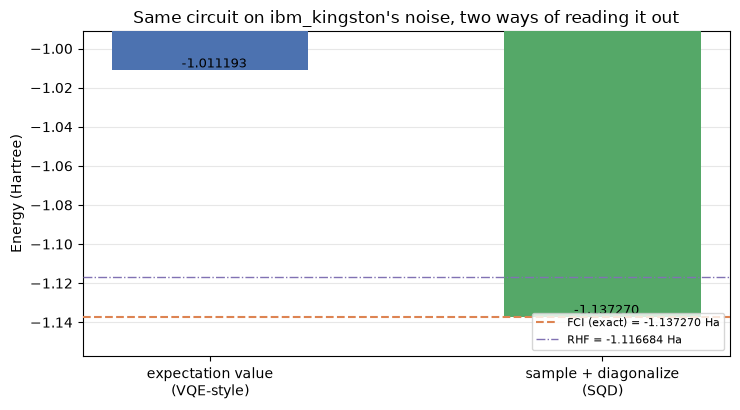

In [16]:

fig, ax = plt.subplots(figsize=(7.5, 4.2))
labels = ['expectation value\n(VQE-style)', 'sample + diagonalize\n(SQD)']
vals = [e_expval, e_sqd]
bars = ax.bar(labels, vals, color=['#4C72B0', '#55A868'], width=0.5, zorder=3)
ax.axhline(e_fci, ls='--', color='#DD8452', zorder=4,
           label=f'FCI (exact) = {e_fci:.6f} Ha')
ax.axhline(mf.e_tot, ls='-.', color='#8172B3', lw=1, zorder=4,
           label=f'RHF = {mf.e_tot:.6f} Ha')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f'  {v:.6f}',
            ha='center', va='bottom' if v > e_fci else 'top', fontsize=9)
lo = min(vals + [e_fci]) - 0.02
hi = max(vals + [mf.e_tot]) + 0.02
ax.set_ylim(lo, hi)
ax.set_ylabel('Energy (Hartree)')
ax.set_title(f"Same circuit on {backend.name}'s noise, two ways of reading it out")
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='y', alpha=0.3, zorder=0)
fig.tight_layout()
plt.show()



**Why SQD wins here, and what that does and does not mean.**

The device is equally noisy in both columns. The difference is entirely in
what the noise can damage:

- An expectation value is a weighted sum of measured Pauli averages. Every
  gate error pushes those averages toward zero, and the resulting energy
  error is *systematic* -- it does not average out, and more shots do not
  remove it. That is why the VQE notebook's runs landed above Hartree-Fock.
- SQD uses the device only to nominate determinants. A corrupted shot
  either lands on a determinant that was going to be in the subspace
  anyway, or on one with the wrong electron count that gets repaired or
  discarded. Once the subspace is fixed, the energy comes from an exact
  classical eigenvalue problem, so it is variational and cannot fall below
  FCI.

Three honest caveats:

- **$\textrm{H}_2$ flatters SQD.** The full CI space here is 4
  determinants, so any halfway-reasonable sampling spans the *entire*
  space and SQD returns FCI exactly. Nothing is being selected. The method's
  real difficulty -- choosing a good small subspace out of an astronomically
  large one -- does not appear at this size.
- **The classical cost is real.** SQD moves work onto the classical side:
  the subspace dimension, and the cost of diagonalizing it, grows with the
  molecule. It is not free, it is *relocated*.
- **Sampling quality still matters.** If the noise is bad enough that the
  important determinants never appear, no amount of recovery invents them.
  SQD degrades gracefully rather than catastrophically, but it does degrade.

The natural next step is a system where the subspace genuinely has to be
chosen: $\textrm{N}_2$/STO-3G with the 1s+2s core frozen leaves 12 active
spin-orbitals and a CI space of several thousand determinants -- large
enough that which ones you sample starts to matter, and small enough that
the exact answer is still computable for comparison.



## Summary

- Built the same $\textrm{H}_2$ pipeline as `H2_VQE_example.ipynb`
  (integrals → Jordan-Wigner Pauli Hamiltonian → UCCSD circuit), this time
  via **`qiskit-nature`** (`PySCFDriver`, `JordanWignerMapper`,
  `UCCSD`/`HartreeFock`) rather than by hand -- confirming first that its
  qubit ordering and Hamiltonian terms match the hand-built version
  exactly, and discovering along the way that its UCCSD sign convention
  does not. Then solved the ground state by **Sample-based Quantum
  Diagonalization** instead of VQE, with the SQD engine itself written
  from scratch rather than via `qiskit-addon-sqd`.
- Projected the Hamiltonian onto a subspace of determinants using the
  Jordan-Wigner Pauli operator directly -- each Pauli string maps one
  computational basis state to exactly one other, so no Slater-Condon
  machinery and **no new sign conventions** were needed. Validated against
  known answers: the HF determinant alone reproduces RHF exactly, and the
  full 4-determinant space reproduces FCI exactly.
- Sampled the transpiled circuit on a **real backend's calibrated noise**
  with a single circuit execution -- against the hundreds of executions VQE
  needed -- and measured how many shots come back with the wrong electron
  count, every one of them a visible gate or readout error.
- Implemented both cleaning strategies: **post-selection** (discard bad
  shots) and **configuration recovery / S-CORE** (repair them, using
  occupancies fed back from the previous iteration's wavefunction), inside
  a self-consistent loop.
- Compared SQD against a VQE-style expectation value **on the same circuit,
  same noise and same shot budget**, with no optimizer in either path. The
  expectation value is biased above FCI; SQD lands on it. The difference is
  structural: noise corrupts which bitstrings appear, but the eigenvalue is
  computed classically and stays variational.
- Flagged the limits honestly: $\textrm{H}_2$'s 4-determinant CI space means
  no subspace *selection* is actually happening here, so this validates the
  machinery rather than demonstrating the method's hard part.
